# Week 3 — Safety-Oriented Error Analysis and Conservative Calibration

Week 3 compares the two strongest Week 2 RandomForest directions. CatBoost is not selected as the main direction here because the main question is safety behavior of the already strongest RandomForest pipelines.

## 1. Imports and configuration

In [2]:
import itertools
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

DATA_DIR = Path("CMAPSSData")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

columns = [
    "unit_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21",
]

target_col = "Remaining Useful Life"

rf_params = {
    "n_estimators": 300,
    "max_depth": 20,
    "min_samples_leaf": 3,
    "min_samples_split": 5,
    "random_state": 42,
    "n_jobs": -1,
}

raw_window_size = 100
raw_excluded_sensor_cols = ["sensor_11"]

aggregated_window_size = 50
edge_window_size = 10
selected_optional_pairs = [
    "edge_means",
    "energy_acceleration",
    "last_first",
    "median_iqr",
    "relative_changes",
]

conservative_shifts = range(0, 31)

## 2. Data loading

In [3]:
def load_cmapss_fd001(data_dir):
    train_df = pd.read_csv(
        data_dir / "train_FD001.txt", sep=r"\s+", header=None, names=columns
    )
    test_df = pd.read_csv(
        data_dir / "test_FD001.txt", sep=r"\s+", header=None, names=columns
    )
    rul_test_df = pd.read_csv(
        data_dir / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"]
    )
    return train_df, test_df, rul_test_df


train_df, test_df, rul_test_df = load_cmapss_fd001(DATA_DIR)

feature_cols = [
    col
    for col in train_df.columns
    if col.startswith("op_setting_") or col.startswith("sensor_")
]

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Official test RUL shape: {rul_test_df.shape}")

Train shape: (20631, 26)
Test shape: (13096, 26)
Official test RUL shape: (100, 1)


## 3. RUL target construction

In [4]:
def add_rul_target(train_df):
    train_df = train_df.copy()
    max_cycle_per_unit = train_df.groupby("unit_id")["cycle"].max()
    train_df[target_col] = (
        train_df["unit_id"].map(max_cycle_per_unit) - train_df["cycle"]
    )
    return train_df


train_df = add_rul_target(train_df)
y_test_official = rul_test_df["RUL"].reset_index(drop=True)

test_unit_ids = (
    test_df.sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)["unit_id"]
    .sort_values()
    .reset_index(drop=True)
)

if len(test_unit_ids) != len(y_test_official):
    raise ValueError("Official test RUL count must match the number of test units")

train_df[["unit_id", "cycle", target_col]].head()

,unit_id,cycle,Remaining Useful Life
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


## Reusable evaluation and plotting functions

In [5]:
def evaluate_regression(y_true, y_pred):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    error = y_pred - y_true
    abs_error = error.abs()
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
        "mean_error": float(error.mean()),
        "median_abs_error": float(abs_error.median()),
        "max_abs_error": float(abs_error.max()),
    }


def build_error_table(unit_ids, y_true, y_pred, model_name):
    error_df = pd.DataFrame(
        {
            "model_name": model_name,
            "unit_id": pd.Series(unit_ids).to_numpy(),
            "true_rul": pd.Series(y_true).to_numpy(),
            "pred_rul": pd.Series(y_pred).to_numpy(),
        }
    )
    error_df["error"] = error_df["pred_rul"] - error_df["true_rul"]
    error_df["abs_error"] = error_df["error"].abs()
    error_df["error_type"] = np.select(
        [error_df["error"] > 0, error_df["error"] < 0],
        ["overestimation", "underestimation"],
        default="exact",
    )
    return error_df


def safety_summary(error_df):
    over_errors = error_df.loc[error_df["error"] > 0, "error"]
    under_errors = error_df.loc[error_df["error"] < 0, "error"]
    return {
        "model_name": error_df["model_name"].iloc[0],
        "MAE": mean_absolute_error(error_df["true_rul"], error_df["pred_rul"]),
        "RMSE": mean_squared_error(error_df["true_rul"], error_df["pred_rul"]) ** 0.5,
        "R2": r2_score(error_df["true_rul"], error_df["pred_rul"]),
        "mean_error": float(error_df["error"].mean()),
        "median_error": float(error_df["error"].median()),
        "median_abs_error": float(error_df["abs_error"].median()),
        "max_abs_error": float(error_df["abs_error"].max()),
        "overestimation_count": int((error_df["error"] > 0).sum()),
        "underestimation_count": int((error_df["error"] < 0).sum()),
        "overestimation_share": float((error_df["error"] > 0).mean()),
        "underestimation_share": float((error_df["error"] < 0).mean()),
        "mean_overestimation": float(over_errors.mean()) if len(over_errors) else 0.0,
        "mean_underestimation": (
            float(under_errors.mean()) if len(under_errors) else 0.0
        ),
        "max_overestimation": float(over_errors.max()) if len(over_errors) else 0.0,
        "max_underestimation": float(under_errors.min()) if len(under_errors) else 0.0,
    }


def assign_rul_zone(true_rul):
    if true_rul <= 30:
        return "near_failure"
    if true_rul <= 70:
        return "warning_zone"
    if true_rul <= 120:
        return "mid_life"
    return "long_rul"


def evaluate_by_rul_zones(error_df):
    zone_df = error_df.copy()
    zone_df["zone"] = zone_df["true_rul"].apply(assign_rul_zone)
    rows = []
    for zone in ["near_failure", "warning_zone", "mid_life", "long_rul"]:
        subset = zone_df[zone_df["zone"] == zone]
        over_errors = subset.loc[subset["error"] > 0, "error"]
        rows.append(
            {
                "model_name": error_df["model_name"].iloc[0],
                "zone": zone,
                "count": len(subset),
                "MAE": (
                    mean_absolute_error(subset["true_rul"], subset["pred_rul"])
                    if len(subset)
                    else np.nan
                ),
                "RMSE": (
                    mean_squared_error(subset["true_rul"], subset["pred_rul"]) ** 0.5
                    if len(subset)
                    else np.nan
                ),
                "mean_error": float(subset["error"].mean()) if len(subset) else np.nan,
                "median_abs_error": (
                    float(subset["abs_error"].median()) if len(subset) else np.nan
                ),
                "overestimation_count": int((subset["error"] > 0).sum()),
                "overestimation_share": (
                    float((subset["error"] > 0).mean()) if len(subset) else np.nan
                ),
                "mean_overestimation": (
                    float(over_errors.mean()) if len(over_errors) else 0.0
                ),
                "max_overestimation": (
                    float(over_errors.max()) if len(over_errors) else 0.0
                ),
            }
        )
    return pd.DataFrame(rows)


def evaluate_conservative_shifts(error_df, shifts):
    rows = []
    model_name = error_df["model_name"].iloc[0]
    for shift in shifts:
        shifted_df = error_df.copy()
        shifted_df["pred_rul"] = np.maximum(shifted_df["pred_rul"] - shift, 0)
        shifted_df["error"] = shifted_df["pred_rul"] - shifted_df["true_rul"]
        shifted_df["abs_error"] = shifted_df["error"].abs()
        shifted_df["error_type"] = np.select(
            [shifted_df["error"] > 0, shifted_df["error"] < 0],
            ["overestimation", "underestimation"],
            default="exact",
        )
        metrics = safety_summary(shifted_df)
        zone_metrics = evaluate_by_rul_zones(shifted_df).set_index("zone")
        rows.append(
            {
                "model_name": model_name,
                "shift": shift,
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "R2": metrics["R2"],
                "mean_error": metrics["mean_error"],
                "median_abs_error": metrics["median_abs_error"],
                "overestimation_count": metrics["overestimation_count"],
                "overestimation_share": metrics["overestimation_share"],
                "mean_overestimation": metrics["mean_overestimation"],
                "max_overestimation": metrics["max_overestimation"],
                "near_failure_MAE": zone_metrics.loc["near_failure", "MAE"],
                "near_failure_overestimation_share": zone_metrics.loc[
                    "near_failure", "overestimation_share"
                ],
                "warning_zone_MAE": zone_metrics.loc["warning_zone", "MAE"],
                "warning_zone_overestimation_share": zone_metrics.loc[
                    "warning_zone", "overestimation_share"
                ],
            }
        )
    return pd.DataFrame(rows)


def select_recommended_shift(
    shift_results, baseline_mae, baseline_over_share, baseline_max_over
):
    candidates = shift_results[
        (shift_results["MAE"] <= baseline_mae * 1.10)
        & (shift_results["overestimation_share"] < baseline_over_share)
        & (shift_results["max_overestimation"] < baseline_max_over)
    ]
    if len(candidates):
        return candidates.sort_values(["MAE", "shift"]).iloc[0]
    return shift_results.sort_values(["MAE", "shift"]).iloc[0]


def plot_true_vs_pred(error_df, title):
    plt.figure(figsize=(12, 5))
    plt.plot(
        error_df["unit_id"],
        error_df["true_rul"],
        marker="o",
        linewidth=2,
        label="True RUL",
    )
    plt.plot(
        error_df["unit_id"],
        error_df["pred_rul"],
        marker="o",
        linewidth=2,
        label="Predicted RUL",
    )
    plt.title(title)
    plt.xlabel("Unit ID")
    plt.ylabel("RUL")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_prediction_error(error_df, title):
    plt.figure(figsize=(12, 5))
    plt.bar(error_df["unit_id"], error_df["error"])
    plt.axhline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("Unit ID")
    plt.ylabel("Prediction error")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_absolute_error_top_units(error_df, title, top_n=15):
    top_df = error_df.sort_values("abs_error", ascending=False).head(top_n)
    plt.figure(figsize=(10, 5))
    plt.bar(top_df["unit_id"].astype(str), top_df["abs_error"])
    plt.title(title)
    plt.xlabel("Unit ID")
    plt.ylabel("Absolute error")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_shift_tradeoff(shift_results, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(shift_results["shift"], shift_results["MAE"], marker="o")
    plt.title(f"{model_name}: conservative shift vs MAE")
    plt.xlabel("Shift")
    plt.ylabel("MAE")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(8, 5))
    plt.plot(shift_results["shift"], shift_results["overestimation_share"], marker="o")
    plt.title(f"{model_name}: conservative shift vs overestimation share")
    plt.xlabel("Shift")
    plt.ylabel("Overestimation share")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_true_original_calibrated(error_df, shift, title):
    calibrated_pred = np.maximum(error_df["pred_rul"] - shift, 0)
    plt.figure(figsize=(12, 5))
    plt.plot(
        error_df["unit_id"],
        error_df["true_rul"],
        marker="o",
        linewidth=2,
        label="True RUL",
    )
    plt.plot(
        error_df["unit_id"],
        error_df["pred_rul"],
        marker="o",
        linewidth=2,
        label="Original prediction",
    )
    plt.plot(
        error_df["unit_id"],
        calibrated_pred,
        marker="o",
        linewidth=2,
        label="Calibrated prediction",
    )
    plt.title(title)
    plt.xlabel("Unit ID")
    plt.ylabel("RUL")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4. Pipeline A: raw lag-window RandomForest baseline

This is the strongest Week 2 pure-score model: a flattened 100-cycle raw window with `sensor_11` excluded.

In [6]:
def build_lag_window_features(
    source_df,
    selected_feature_cols,
    window_size,
    include_target=False,
    require_full_window=False,
):
    sorted_df = source_df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
    first_values = sorted_df.groupby("unit_id")[selected_feature_cols].transform(
        "first"
    )
    lagged_parts = []
    for lag in range(window_size - 1, -1, -1):
        shifted = sorted_df.groupby("unit_id")[selected_feature_cols].shift(lag)
        if not require_full_window:
            shifted = shifted.fillna(first_values)
        suffix = "t" if lag == 0 else f"t_minus_{lag}"
        shifted.columns = [f"{col}_{suffix}" for col in selected_feature_cols]
        lagged_parts.append(shifted)
    metadata_cols = ["unit_id", "cycle"]
    if include_target:
        metadata_cols.append(target_col)
    result_df = pd.concat([sorted_df[metadata_cols], *lagged_parts], axis=1)
    if require_full_window:
        result_df = result_df[result_df["cycle"] >= window_size].dropna()
    return result_df.reset_index(drop=True)


raw_feature_cols = [col for col in feature_cols if col not in raw_excluded_sensor_cols]

raw_window_train_df = build_lag_window_features(
    train_df,
    selected_feature_cols=raw_feature_cols,
    window_size=raw_window_size,
    include_target=True,
    require_full_window=True,
)
raw_window_test_df = build_lag_window_features(
    test_df,
    selected_feature_cols=raw_feature_cols,
    window_size=raw_window_size,
    include_target=False,
    require_full_window=False,
)

raw_window_feature_cols = [
    col
    for col in raw_window_train_df.columns
    if col not in ["unit_id", "cycle", target_col]
]
raw_window_test_last_rows = (
    raw_window_test_df.sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_train_raw = raw_window_train_df[raw_window_feature_cols]
y_train_raw = raw_window_train_df[target_col].reset_index(drop=True)
X_test_raw = raw_window_test_last_rows[raw_window_feature_cols]
y_test_raw = y_test_official
raw_test_unit_ids = raw_window_test_last_rows["unit_id"].reset_index(drop=True)

if len(X_test_raw) != len(y_test_raw):
    raise ValueError("Raw-window test feature rows must match official RUL rows")

raw_model = RandomForestRegressor(**rf_params)
raw_train_start = time.perf_counter()
raw_model.fit(X_train_raw, y_train_raw)
raw_train_seconds = time.perf_counter() - raw_train_start
raw_pred = raw_model.predict(X_test_raw)

raw_metrics = evaluate_regression(y_test_raw, raw_pred)
raw_error_df = build_error_table(
    raw_test_unit_ids, y_test_raw, raw_pred, "Pipeline A: raw lag-window RF"
)

print(f"Raw-window train rows: {X_train_raw.shape[0]}")
print(f"Raw-window feature count: {X_train_raw.shape[1]}")
print(f"Raw-window train seconds: {raw_train_seconds:.2f}")
pd.DataFrame([raw_metrics])

Raw-window train rows: 10731
Raw-window feature count: 2300
Raw-window train seconds: 222.79


,MAE,RMSE,R2,mean_error,median_abs_error,max_abs_error
0,13.299888,17.901184,0.814432,3.106353,8.946425,70.352008


## 5. Pipeline B: aggregated-feature RandomForest baseline

This is the best targeted aggregated Week 2 pipeline. It is much faster and keeps feature blocks interpretable.

In [7]:
extended_agg_feature_cols = feature_cols
eps = 1e-8

mandatory_feature_blocks = [
    "mean",
    "std",
    "min",
    "max",
    "range",
    "delta",
    "slope",
    "last_minus_mean",
]

optional_feature_pairs = {
    "median_iqr": ["median", "iqr"],
    "last_first": ["last", "first"],
    "relative_changes": ["relative_delta", "relative_last_minus_mean"],
    "edge_means": ["mean_last_10", "mean_first_10"],
    "energy_acceleration": ["rms", "slope_change"],
}

selected_optional_blocks = list(
    itertools.chain.from_iterable(
        optional_feature_pairs[pair_name] for pair_name in selected_optional_pairs
    )
)
selected_agg_blocks = mandatory_feature_blocks + selected_optional_blocks


def calculate_slope(values):
    x = np.arange(len(values))
    x = x - x.mean()
    denominator = (x**2).sum()
    if denominator == 0:
        return 0
    return np.dot(values, x) / denominator


def calculate_first_edge_mean(values):
    return values[:edge_window_size].mean()


def calculate_rms(values):
    return np.sqrt(np.mean(values**2))


def calculate_slope_change(values):
    split_index = len(values) // 2
    if split_index == 0 or split_index == len(values):
        return 0
    return calculate_slope(values[split_index:]) - calculate_slope(values[:split_index])


def rename_feature_block(block, suffix):
    renamed_block = block.copy()
    renamed_block.columns = [
        f"{col}_{suffix}_{aggregated_window_size}" for col in renamed_block.columns
    ]
    return renamed_block

In [8]:
def build_all_agg_window_features(
    source_df, include_target=False, require_full_window=False
):
    sorted_df = source_df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
    min_periods = aggregated_window_size if require_full_window else 1
    edge_min_periods = edge_window_size if require_full_window else 1
    rolling_features = sorted_df.groupby("unit_id")[extended_agg_feature_cols].rolling(
        window=aggregated_window_size,
        min_periods=min_periods,
    )
    edge_rolling_features = sorted_df.groupby("unit_id")[
        extended_agg_feature_cols
    ].rolling(
        window=edge_window_size,
        min_periods=edge_min_periods,
    )
    mean_features = rolling_features.mean().reset_index(level=0, drop=True)
    std_features = (
        rolling_features.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    )
    min_features = rolling_features.min().reset_index(level=0, drop=True)
    max_features = rolling_features.max().reset_index(level=0, drop=True)
    median_features = rolling_features.median().reset_index(level=0, drop=True)
    q25_features = rolling_features.quantile(0.25).reset_index(level=0, drop=True)
    q75_features = rolling_features.quantile(0.75).reset_index(level=0, drop=True)
    range_features = max_features - min_features
    iqr_features = q75_features - q25_features
    first_features = sorted_df.groupby("unit_id")[extended_agg_feature_cols].shift(
        aggregated_window_size - 1
    )
    if not require_full_window:
        first_available_values = sorted_df.groupby("unit_id")[
            extended_agg_feature_cols
        ].transform("first")
        first_features = first_features.fillna(first_available_values)
    last_features = sorted_df[extended_agg_feature_cols]
    delta_features = last_features - first_features
    last_minus_mean_features = last_features - mean_features
    relative_delta_features = delta_features / (first_features.abs() + eps)
    relative_last_minus_mean_features = last_minus_mean_features / (
        mean_features.abs() + eps
    )
    mean_last_10_features = edge_rolling_features.mean().reset_index(level=0, drop=True)
    mean_first_10_features = rolling_features.apply(
        calculate_first_edge_mean,
        raw=True,
    ).reset_index(level=0, drop=True)
    slope_features = rolling_features.apply(
        calculate_slope,
        raw=True,
    ).reset_index(level=0, drop=True)
    rms_features = rolling_features.apply(
        calculate_rms,
        raw=True,
    ).reset_index(level=0, drop=True)
    slope_change_features = rolling_features.apply(
        calculate_slope_change,
        raw=True,
    ).reset_index(level=0, drop=True)
    feature_blocks = {
        "mean": mean_features,
        "std": std_features,
        "min": min_features,
        "max": max_features,
        "range": range_features,
        "delta": delta_features,
        "slope": slope_features,
        "last_minus_mean": last_minus_mean_features,
        "median": median_features,
        "iqr": iqr_features,
        "first": first_features,
        "last": last_features,
        "relative_delta": relative_delta_features,
        "relative_last_minus_mean": relative_last_minus_mean_features,
        "mean_first_10": mean_first_10_features,
        "mean_last_10": mean_last_10_features,
        "rms": rms_features,
        "slope_change": slope_change_features,
    }
    metadata_cols = ["unit_id", "cycle"]
    if include_target:
        metadata_cols.append(target_col)
    renamed_feature_blocks = {
        suffix: rename_feature_block(block, suffix)
        for suffix, block in feature_blocks.items()
    }
    result_df = pd.concat(
        [sorted_df[metadata_cols], *renamed_feature_blocks.values()], axis=1
    )
    if require_full_window:
        result_df = result_df[result_df["cycle"] >= aggregated_window_size].dropna()
    feature_block_columns = {
        suffix: list(block.columns) for suffix, block in renamed_feature_blocks.items()
    }
    return result_df.reset_index(drop=True), feature_block_columns


def feature_columns_for_blocks(feature_block_columns, block_names):
    selected_columns = []
    for block_name in block_names:
        selected_columns.extend(feature_block_columns[block_name])
    return selected_columns

In [9]:
agg_train_df, agg_feature_block_columns = build_all_agg_window_features(
    train_df,
    include_target=True,
    require_full_window=True,
)
agg_test_df, _ = build_all_agg_window_features(
    test_df,
    include_target=False,
    require_full_window=False,
)

agg_feature_cols = feature_columns_for_blocks(
    agg_feature_block_columns, selected_agg_blocks
)
agg_test_last_rows = (
    agg_test_df.sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

X_train_agg = agg_train_df[agg_feature_cols]
y_train_agg = agg_train_df[target_col].reset_index(drop=True)
X_test_agg = agg_test_last_rows[agg_feature_cols]
y_test_agg = y_test_official
agg_test_unit_ids = agg_test_last_rows["unit_id"].reset_index(drop=True)

if len(X_test_agg) != len(y_test_agg):
    raise ValueError("Aggregated-feature test rows must match official RUL rows")

agg_model = RandomForestRegressor(**rf_params)
agg_train_start = time.perf_counter()
agg_model.fit(X_train_agg, y_train_agg)
agg_train_seconds = time.perf_counter() - agg_train_start
agg_pred = agg_model.predict(X_test_agg)

agg_metrics = evaluate_regression(y_test_agg, agg_pred)
agg_error_df = build_error_table(
    agg_test_unit_ids, y_test_agg, agg_pred, "Pipeline B: aggregated-feature RF"
)

print(f"Aggregated train rows: {X_train_agg.shape[0]}")
print(f"Aggregated feature count: {X_train_agg.shape[1]}")
print(f"Aggregated train seconds: {agg_train_seconds:.2f}")
pd.DataFrame([agg_metrics])

Aggregated train rows: 15731
Aggregated feature count: 432
Aggregated train seconds: 61.45


,MAE,RMSE,R2,mean_error,median_abs_error,max_abs_error
0,13.378653,20.502347,0.756585,7.716741,7.128084,82.093908


## 6. Global metric comparison

In [10]:
model_comparison_df = pd.DataFrame(
    [
        {
            "model_name": "Pipeline A: raw lag-window RF",
            "feature_type": "raw_lag_window",
            "window_size": raw_window_size,
            "feature_count": X_train_raw.shape[1],
            "train_seconds": raw_train_seconds,
            **evaluate_regression(y_test_raw, raw_pred),
        },
        {
            "model_name": "Pipeline B: aggregated-feature RF",
            "feature_type": "aggregated_features",
            "window_size": aggregated_window_size,
            "feature_count": X_train_agg.shape[1],
            "train_seconds": agg_train_seconds,
            **evaluate_regression(y_test_agg, agg_pred),
        },
    ]
)

model_comparison_df.to_csv(OUTPUT_DIR / "week3_model_comparison.csv", index=False)
model_comparison_df

,model_name,feature_type,window_size,feature_count,train_seconds,MAE,RMSE,R2,mean_error,median_abs_error,max_abs_error
0,Pipeline A: raw lag-window RF,raw_lag_window,100,2300,222.788113,13.299888,17.901184,0.814432,3.106353,8.946425,70.352008
1,Pipeline B: aggregated-feature RF,aggregated_features,50,432,61.445239,13.378653,20.502347,0.756585,7.716741,7.128084,82.093908


## 7. Unit-level error analysis

In [11]:
raw_error_df.to_csv(OUTPUT_DIR / "week3_raw_window_error_table.csv", index=False)
agg_error_df.to_csv(OUTPUT_DIR / "week3_aggregated_error_table.csv", index=False)

for error_df in [raw_error_df, agg_error_df]:
    model_name = error_df["model_name"].iloc[0]
    print()
    print(f"{model_name}: top 15 worst units by absolute error")
    display(error_df.sort_values("abs_error", ascending=False).head(15))
    print()
    print(f"{model_name}: top 10 unsafe overestimations")
    display(
        error_df[error_df["error"] > 0].sort_values("error", ascending=False).head(10)
    )
    print()
    print(f"{model_name}: top 10 conservative underestimations")
    display(
        error_df[error_df["error"] < 0].sort_values("error", ascending=True).head(10)
    )


Pipeline A: raw lag-window RF: top 15 worst units by absolute error


,model_name,unit_id,true_rul,pred_rul,error,abs_error,error_type
14,Pipeline A: raw lag-window RF,15,83,153.352008,70.352008,70.352008,overestimation
92,Pipeline A: raw lag-window RF,93,85,43.468411,-41.531589,41.531589,underestimation
15,Pipeline A: raw lag-window RF,16,84,124.180004,40.180004,40.180004,overestimation
46,Pipeline A: raw lag-window RF,47,135,98.298612,-36.701388,36.701388,underestimation
88,Pipeline A: raw lag-window RF,89,136,99.729690,-36.270310,36.270310,underestimation
49,Pipeline A: raw lag-window RF,50,79,114.390555,35.390555,35.390555,overestimation
47,Pipeline A: raw lag-window RF,48,92,126.282493,34.282493,34.282493,overestimation
78,Pipeline A: raw lag-window RF,79,63,96.835118,33.835118,33.835118,overestimation
77,Pipeline A: raw lag-window RF,78,107,139.819265,32.819265,32.819265,overestimation
73,Pipeline A: raw lag-window RF,74,126,93.906793,-32.093207,32.093207,underestimation



Pipeline A: raw lag-window RF: top 10 unsafe overestimations


,model_name,unit_id,true_rul,pred_rul,error,abs_error,error_type
14,Pipeline A: raw lag-window RF,15,83,153.352008,70.352008,70.352008,overestimation
15,Pipeline A: raw lag-window RF,16,84,124.180004,40.180004,40.180004,overestimation
49,Pipeline A: raw lag-window RF,50,79,114.390555,35.390555,35.390555,overestimation
47,Pipeline A: raw lag-window RF,48,92,126.282493,34.282493,34.282493,overestimation
78,Pipeline A: raw lag-window RF,79,63,96.835118,33.835118,33.835118,overestimation
77,Pipeline A: raw lag-window RF,78,107,139.819265,32.819265,32.819265,overestimation
0,Pipeline A: raw lag-window RF,1,112,143.177993,31.177993,31.177993,overestimation
26,Pipeline A: raw lag-window RF,27,66,96.687490,30.687490,30.687490,overestimation
21,Pipeline A: raw lag-window RF,22,111,139.281235,28.281235,28.281235,overestimation
53,Pipeline A: raw lag-window RF,54,97,123.552204,26.552204,26.552204,overestimation



Pipeline A: raw lag-window RF: top 10 conservative underestimations


...

,model_name,unit_id,true_rul,pred_rul,error,abs_error,error_type
66,Pipeline B: aggregated-feature RF,67,77,159.093908,82.093908,82.093908,overestimation
47,Pipeline B: aggregated-feature RF,48,92,166.983898,74.983898,74.983898,overestimation
5,Pipeline B: aggregated-feature RF,6,93,163.987672,70.987672,70.987672,overestimation
77,Pipeline B: aggregated-feature RF,78,107,160.213903,53.213903,53.213903,overestimation
53,Pipeline B: aggregated-feature RF,54,97,140.541799,43.541799,43.541799,overestimation
74,Pipeline B: aggregated-feature RF,75,113,150.193337,37.193337,37.193337,overestimation
64,Pipeline B: aggregated-feature RF,65,128,164.504272,36.504272,36.504272,overestimation
78,Pipeline B: aggregated-feature RF,79,63,99.164589,36.164589,36.164589,overestimation
82,Pipeline B: aggregated-feature RF,83,137,171.441414,34.441414,34.441414,overestimation
9,Pipeline B: aggregated-feature RF,10,96,62.284764,-33.715236,33.715236,underestimation



Pipeline B: aggregated-feature RF: top 10 unsafe overestimations


,model_name,unit_id,true_rul,pred_rul,error,abs_error,error_type
66,Pipeline B: aggregated-feature RF,67,77,159.093908,82.093908,82.093908,overestimation
47,Pipeline B: aggregated-feature RF,48,92,166.983898,74.983898,74.983898,overestimation
5,Pipeline B: aggregated-feature RF,6,93,163.987672,70.987672,70.987672,overestimation
77,Pipeline B: aggregated-feature RF,78,107,160.213903,53.213903,53.213903,overestimation
53,Pipeline B: aggregated-feature RF,54,97,140.541799,43.541799,43.541799,overestimation
74,Pipeline B: aggregated-feature RF,75,113,150.193337,37.193337,37.193337,overestimation
64,Pipeline B: aggregated-feature RF,65,128,164.504272,36.504272,36.504272,overestimation
78,Pipeline B: aggregated-feature RF,79,63,99.164589,36.164589,36.164589,overestimation
82,Pipeline B: aggregated-feature RF,83,137,171.441414,34.441414,34.441414,overestimation
21,Pipeline B: aggregated-feature RF,22,111,142.587553,31.587553,31.587553,overestimation



Pipeline B: aggregated-feature RF: top 10 conservative underestimations


,model_name,unit_id,true_rul,pred_rul,error,abs_error,error_type
9,Pipeline B: aggregated-feature RF,10,96,62.284764,-33.715236,33.715236,underestimation
11,Pipeline B: aggregated-feature RF,12,124,93.602719,-30.397281,30.397281,underestimation
29,Pipeline B: aggregated-feature RF,30,115,88.776968,-26.223032,26.223032,underestimation
92,Pipeline B: aggregated-feature RF,93,85,61.253391,-23.746609,23.746609,underestimation
88,Pipeline B: aggregated-feature RF,89,136,114.867892,-21.132108,21.132108,underestimation
72,Pipeline B: aggregated-feature RF,73,131,111.065114,-19.934886,19.934886,underestimation
79,Pipeline B: aggregated-feature RF,80,90,73.057260,-16.942740,16.942740,underestimation
46,Pipeline B: aggregated-feature RF,47,135,122.934042,-12.065958,12.065958,underestimation
90,Pipeline B: aggregated-feature RF,91,38,26.408140,-11.591860,11.591860,underestimation
7,Pipeline B: aggregated-feature RF,8,95,85.671444,-9.328556,9.328556,underestimation


## 8. RUL-zone safety analysis

Overestimation is the safety-critical side of the error distribution because it predicts more remaining life than actually available.

In [12]:
safety_summary_df = pd.DataFrame(
    [
        safety_summary(raw_error_df),
        safety_summary(agg_error_df),
    ]
)
safety_summary_df.to_csv(OUTPUT_DIR / "week3_safety_summary.csv", index=False)
safety_summary_df

,model_name,MAE,RMSE,R2,mean_error,median_error,median_abs_error,max_abs_error,overestimation_count,underestimation_count,overestimation_share,underestimation_share,mean_overestimation,mean_underestimation,max_overestimation,max_underestimation
0,Pipeline A: raw lag-window RF,13.299888,17.901184,0.814432,3.106353,4.231536,8.946425,70.352008,60,40,0.6,0.4,13.671868,-12.741919,70.352008,-41.531589
1,Pipeline B: aggregated-feature RF,13.378653,20.502347,0.756585,7.716741,4.565794,7.128084,82.093908,70,30,0.7,0.3,15.068139,-9.436521,82.093908,-33.715236


In [13]:
rul_zone_summary_df = pd.concat(
    [
        evaluate_by_rul_zones(raw_error_df),
        evaluate_by_rul_zones(agg_error_df),
    ],
    ignore_index=True,
)
rul_zone_summary_df.to_csv(OUTPUT_DIR / "week3_rul_zone_summary.csv", index=False)
rul_zone_summary_df

,model_name,zone,count,MAE,RMSE,mean_error,median_abs_error,overestimation_count,overestimation_share,mean_overestimation,max_overestimation
0,Pipeline A: raw lag-window RF,near_failure,25,6.312309,8.234157,5.519099,5.034497,18,0.720000,8.216255,18.661150
1,Pipeline A: raw lag-window RF,warning_zone,17,10.776340,14.652891,8.832652,7.316747,14,0.823529,11.905459,33.835118
2,Pipeline A: raw lag-window RF,mid_life,45,17.297518,21.742430,4.876147,14.199504,26,0.577778,19.188749,70.352008
3,Pipeline A: raw lag-window RF,long_rul,13,16.199619,20.432224,-15.147991,8.997644,2,0.153846,3.417790,5.625344
4,Pipeline B: aggregated-feature RF,near_failure,25,3.499732,4.140448,1.701858,3.313214,20,0.800000,3.250994,8.463654
5,Pipeline B: aggregated-feature RF,warning_zone,17,8.757764,12.092116,5.148082,5.988109,11,0.647059,10.745426,36.164589
6,Pipeline B: aggregated-feature RF,mid_life,45,19.652087,27.427041,13.355734,15.502853,32,0.711111,23.208625,82.093908
7,Pipeline B: aggregated-feature RF,long_rul,13,16.703546,20.133012,3.123247,17.847820,7,0.538462,18.410593,36.504272


## 9. Conservative calibration

A conservative shift subtracts a fixed amount from every prediction and clips at zero. This can reduce unsafe overestimation, sometimes at the cost of worse MAE.

In [14]:
raw_shift_results = evaluate_conservative_shifts(raw_error_df, conservative_shifts)
agg_shift_results = evaluate_conservative_shifts(agg_error_df, conservative_shifts)

raw_shift_results.to_csv(OUTPUT_DIR / "week3_raw_window_shift_results.csv", index=False)
agg_shift_results.to_csv(OUTPUT_DIR / "week3_aggregated_shift_results.csv", index=False)

recommendation_rows = []
for error_df, shift_results in [
    (raw_error_df, raw_shift_results),
    (agg_error_df, agg_shift_results),
]:
    baseline = safety_summary(error_df)
    best_mae = shift_results.sort_values(["MAE", "shift"]).iloc[0]
    best_max_over = shift_results.sort_values(
        ["max_overestimation", "MAE", "shift"]
    ).iloc[0]
    best_near_failure_over = shift_results.sort_values(
        ["near_failure_overestimation_share", "MAE", "shift"]
    ).iloc[0]
    balanced = select_recommended_shift(
        shift_results,
        baseline_mae=baseline["MAE"],
        baseline_over_share=baseline["overestimation_share"],
        baseline_max_over=baseline["max_overestimation"],
    )
    for selection_type, row in [
        ("best_MAE", best_mae),
        ("best_max_overestimation", best_max_over),
        ("best_near_failure_overestimation_share", best_near_failure_over),
        ("balanced_recommended", balanced),
    ]:
        recommendation_rows.append(
            {
                "model_name": baseline["model_name"],
                "selection_type": selection_type,
                "shift": row["shift"],
                "MAE": row["MAE"],
                "RMSE": row["RMSE"],
                "R2": row["R2"],
                "overestimation_share": row["overestimation_share"],
                "max_overestimation": row["max_overestimation"],
                "near_failure_MAE": row["near_failure_MAE"],
                "near_failure_overestimation_share": row[
                    "near_failure_overestimation_share"
                ],
                "warning_zone_MAE": row["warning_zone_MAE"],
                "warning_zone_overestimation_share": row[
                    "warning_zone_overestimation_share"
                ],
            }
        )

shift_recommendations_df = pd.DataFrame(recommendation_rows)
shift_recommendations_df.to_csv(
    OUTPUT_DIR / "week3_shift_recommendations.csv", index=False
)
shift_recommendations_df

,model_name,selection_type,shift,MAE,RMSE,R2,overestimation_share,max_overestimation,near_failure_MAE,near_failure_overestimation_share,warning_zone_MAE,warning_zone_overestimation_share
0,Pipeline A: raw lag-window RF,best_MAE,4,12.880233,17.652240,0.819557,0.50,66.352008,4.956922,0.60,9.059359,0.647059
1,Pipeline A: raw lag-window RF,best_max_overestimation,30,25.961848,30.667287,0.455383,0.08,40.352008,15.255710,0.00,21.699420,0.117647
2,Pipeline A: raw lag-window RF,best_near_failure_overestimation_share,19,18.947915,23.302618,0.685551,0.13,51.352008,10.545738,0.00,14.160373,0.176471
3,Pipeline A: raw lag-window RF,balanced_recommended,4,12.880233,17.652240,0.819557,0.50,66.352008,4.956922,0.60,9.059359,0.647059
4,Pipeline B: aggregated-feature RF,best_MAE,5,12.511970,19.187986,0.786794,0.48,77.093908,3.833667,0.16,8.065104,0.529412
5,Pipeline B: aggregated-feature RF,best_max_overestimation,30,23.491273,27.125119,0.573927,0.10,52.093908,17.264498,0.00,25.295860,0.058824
6,Pipeline B: aggregated-feature RF,best_near_failure_overestimation_share,9,13.289804,19.013188,0.790661,0.34,73.093908,7.122941,0.00,8.989131,0.294118
7,Pipeline B: aggregated-feature RF,balanced_recommended,5,12.511970,19.187986,0.786794,0.48,77.093908,3.833667,0.16,8.065104,0.529412


## Plots

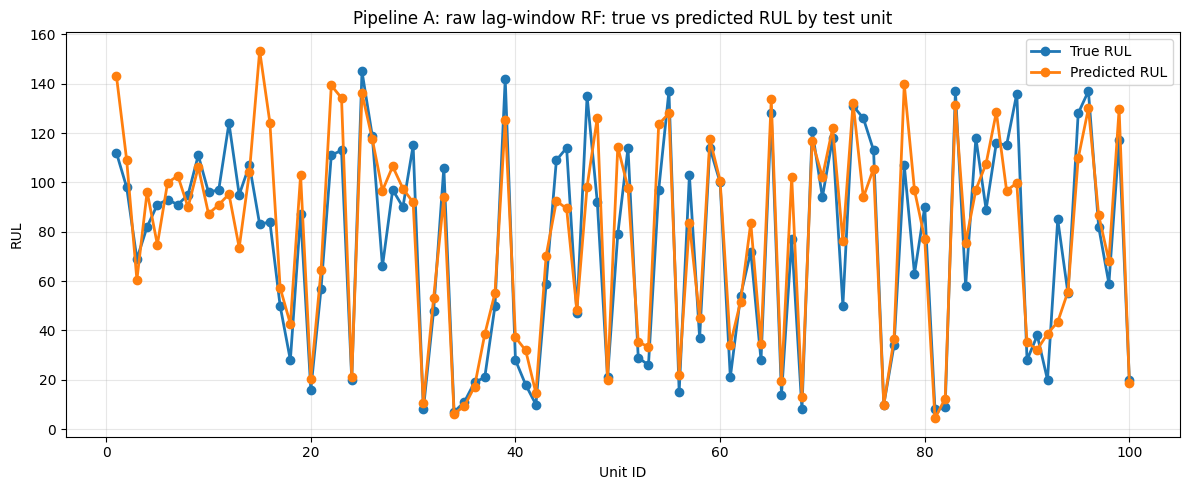

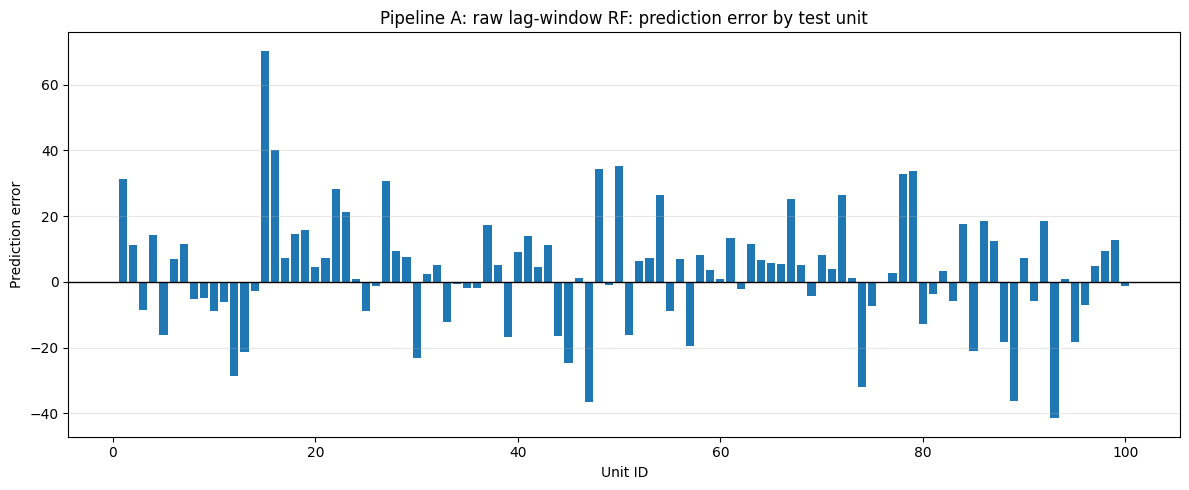

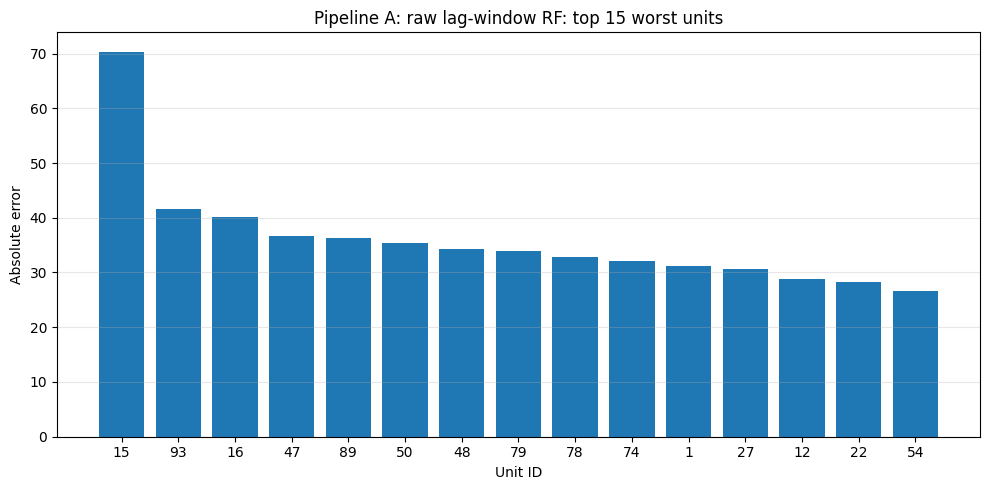

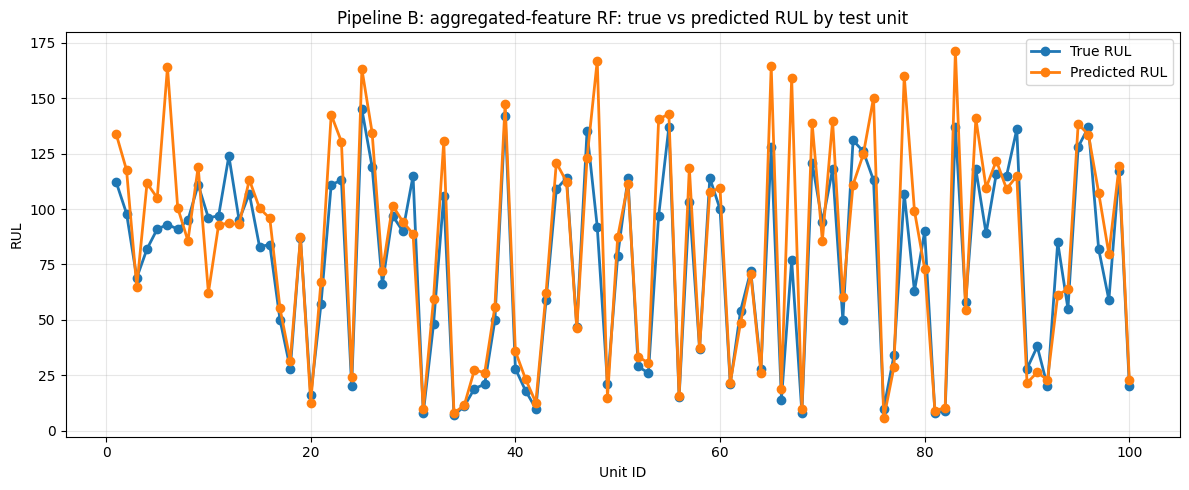

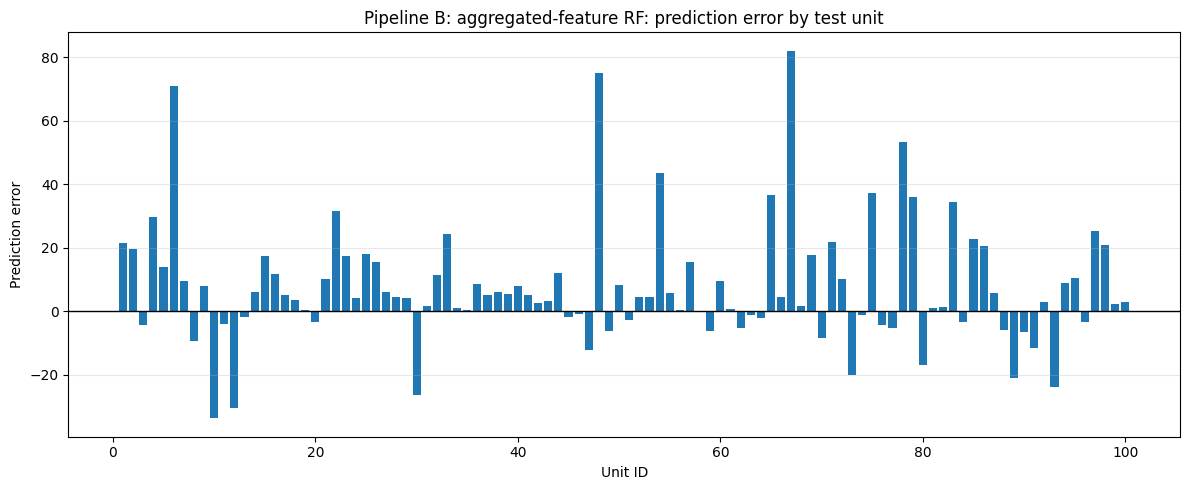

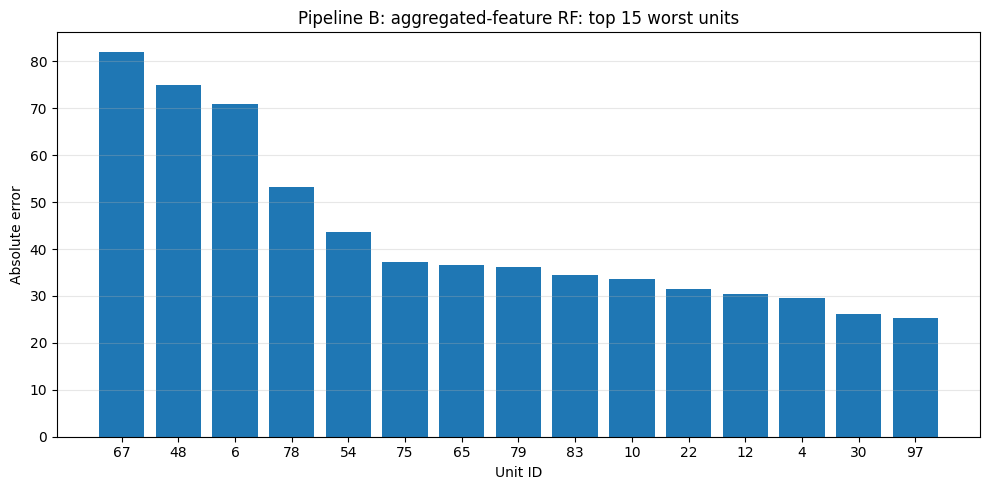

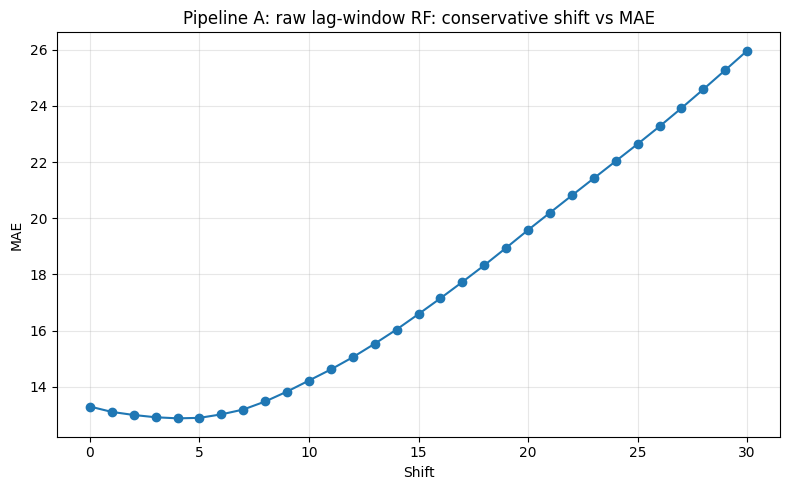

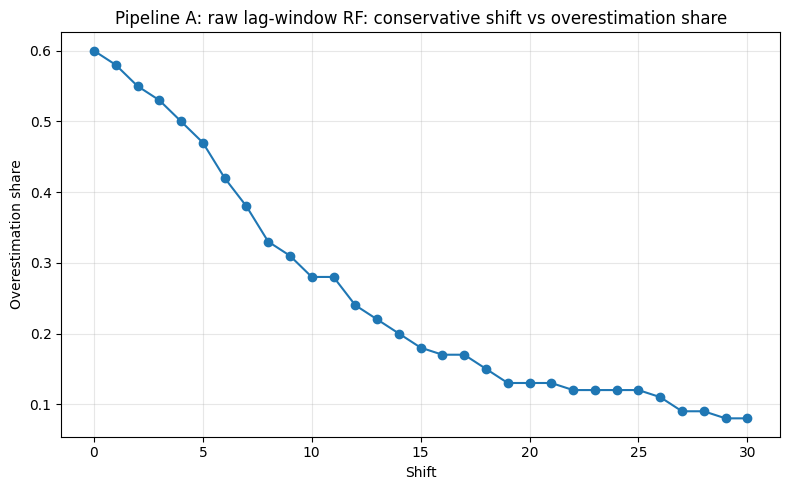

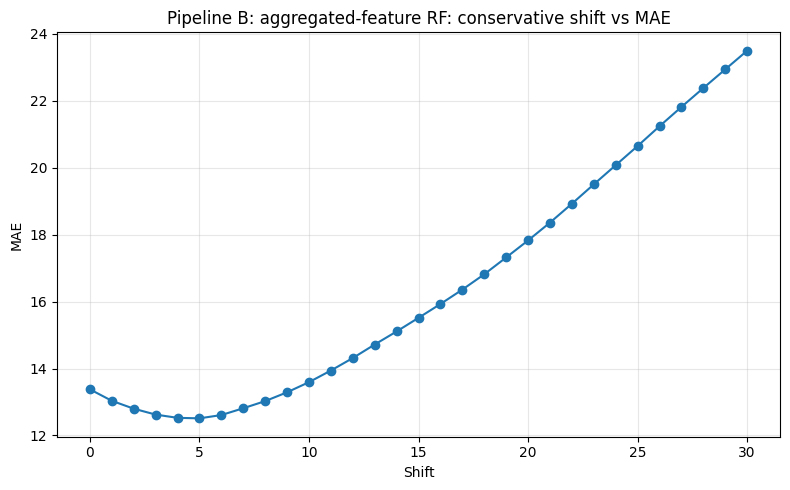

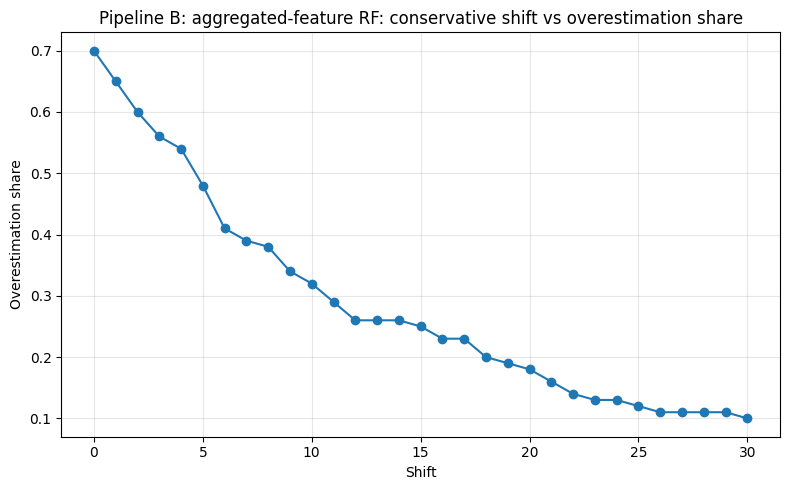

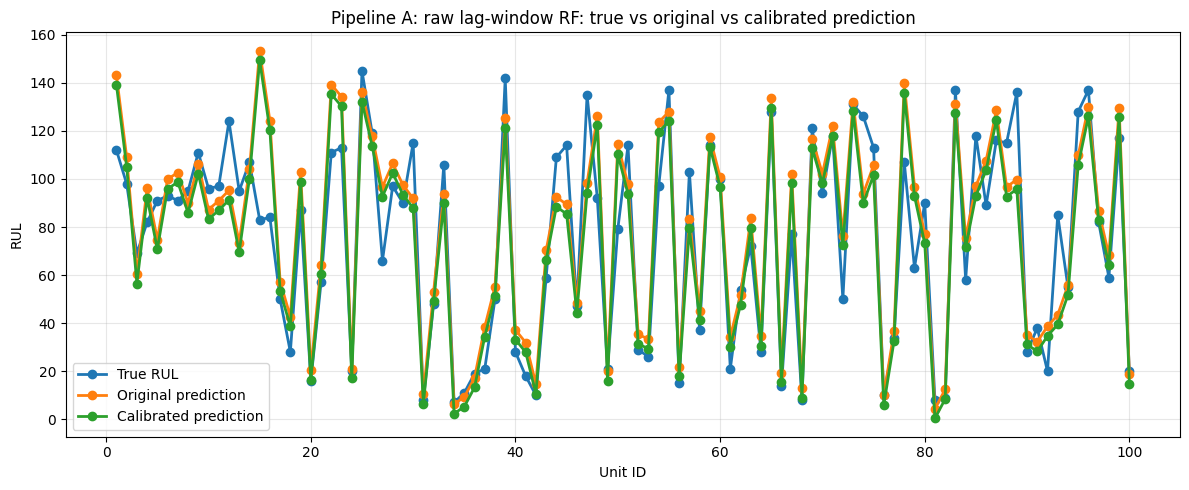

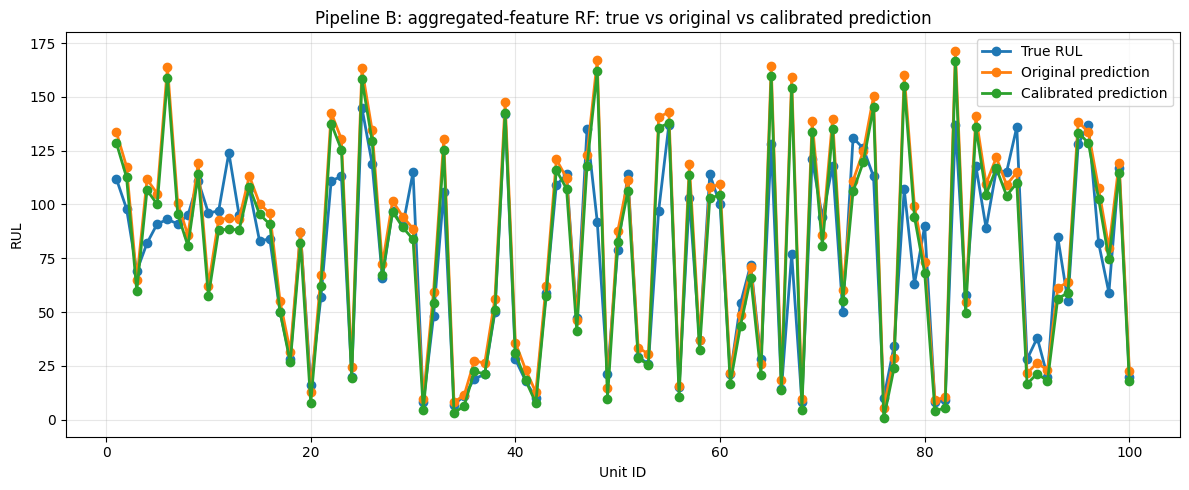

In [15]:
for error_df in [raw_error_df, agg_error_df]:
    model_name = error_df["model_name"].iloc[0]
    plot_true_vs_pred(error_df, f"{model_name}: true vs predicted RUL by test unit")
    plot_prediction_error(error_df, f"{model_name}: prediction error by test unit")
    plot_absolute_error_top_units(
        error_df, f"{model_name}: top 15 worst units", top_n=15
    )

plot_shift_tradeoff(raw_shift_results, "Pipeline A: raw lag-window RF")
plot_shift_tradeoff(agg_shift_results, "Pipeline B: aggregated-feature RF")

balanced_recommendations = shift_recommendations_df[
    shift_recommendations_df["selection_type"] == "balanced_recommended"
]
for error_df in [raw_error_df, agg_error_df]:
    model_name = error_df["model_name"].iloc[0]
    shift = int(
        balanced_recommendations.loc[
            balanced_recommendations["model_name"] == model_name, "shift"
        ].iloc[0]
    )
    plot_true_original_calibrated(
        error_df, shift, f"{model_name}: true vs original vs calibrated prediction"
    )

## 10. Final comparison and conclusions

The raw lag-window RandomForest remains the best pure-score model from Week 2. It uses a large flattened 100-cycle window and delivers the strongest MAE/RMSE/R2, but it is expensive to train and less interpretable.

The aggregated-feature RandomForest is much faster and only slightly worse in MAE. Its feature blocks make it easier to reason about degradation behavior, and its shorter iteration time makes it more practical for analysis.

From a safety-oriented RUL perspective, MAE alone is not enough. Overestimation is more critical than underestimation because it means the model predicts more remaining life than actually available. Near-failure behavior and overestimation rate should therefore be part of the final decision.

Conservative calibration shifts predictions downward. This can reduce unsafe overestimation, sometimes at the cost of slightly worse MAE. The final recommendation should be based not only on MAE, but also on near-failure errors and overestimation rate.

In [16]:
final_recommendation_rows = []
train_seconds_by_model = {
    "Pipeline A: raw lag-window RF": raw_train_seconds,
    "Pipeline B: aggregated-feature RF": agg_train_seconds,
}

for error_df, shift_results in [
    (raw_error_df, raw_shift_results),
    (agg_error_df, agg_shift_results),
]:
    model_name = error_df["model_name"].iloc[0]
    baseline = safety_summary(error_df)
    recommended = shift_recommendations_df[
        (shift_recommendations_df["model_name"] == model_name)
        & (shift_recommendations_df["selection_type"] == "balanced_recommended")
    ].iloc[0]
    final_recommendation_rows.append(
        {
            "model_name": model_name,
            "original_MAE": baseline["MAE"],
            "original_overestimation_share": baseline["overestimation_share"],
            "recommended_shift": recommended["shift"],
            "calibrated_MAE": recommended["MAE"],
            "calibrated_overestimation_share": recommended["overestimation_share"],
            "calibrated_near_failure_MAE": recommended["near_failure_MAE"],
            "train_seconds": train_seconds_by_model[model_name],
        }
    )

final_recommendation_df = pd.DataFrame(final_recommendation_rows)
final_recommendation_df

,model_name,original_MAE,original_overestimation_share,recommended_shift,calibrated_MAE,calibrated_overestimation_share,calibrated_near_failure_MAE,train_seconds
0,Pipeline A: raw lag-window RF,13.299888,0.6,4,12.880233,0.50,4.956922,222.788113
1,Pipeline B: aggregated-feature RF,13.378653,0.7,5,12.511970,0.48,3.833667,61.445239
